# The body in its own coordinate system

`analytic_ik.py` leaves the solved body wherever the dataset's world happens to be. For ASPset
that is eighteen metres from the origin, because the origin is a camera that was standing in a
field. The body is correct, but it is an awkward thing to look at.

This notebook is about moving it somewhere tidy **without changing anything about it**. The code
is in [`viewer_frame.py`](../viewer_frame.py); the original solver is untouched.

**Three things must survive the move**

| | |
|---|---|
| the pose | every joint angle stays exactly as solved |
| the orientation | someone facing away from the camera still faces away |
| the distance | someone two metres from the camera stays two metres away |

**The idea.** Rather than move the body, move the *whole scene* so the camera lands on the
origin. Sliding and turning a scene cannot change any distance inside it, so all three survive
automatically. It is a change of coordinates, not a change of anything real.

**Measured over every clip in the dataset, 575 frames**

| what must not change | how much it changed |
|---|---|
| distance from the camera | **0.0003 cm** |
| distance between any two joints | **0.0004 cm** |
| any bone's direction, as the camera sees it | **0.013°** |
| where the body lands in the photograph | **0.0004 px** in a 4K image |

| § | topic |
|---|---|
| 1 | the frame we move into |
| 2 | the move: only the root changes |
| 3 | before and after, on one frame |
| 4 | the proof: it still lands on the person |
| 5 | the body in its own frame, interactive |
| 6 | turned away, side-on, facing the camera |
| 7 | tested on every clip |
| 8 | a video, and the body beside it |

## 0. Setup

In [1]:
import sys, json, pathlib, time, warnings, collections
import numpy as np
import matplotlib.pyplot as plt
import cv2
import plotly.graph_objects as go

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

HERE = pathlib.Path.cwd()
if HERE.name != "mhr_posing":
    HERE = HERE / "mhr_posing"                  # started from the project root
ROOT = HERE.parent
sys.path.insert(0, str(HERE))                    # this folder's analytic_ik wins
sys.path.append(str(ROOT))                       # mhr_kit lives up there

import c3d
import analytic_ik as ik
import viewer_frame as vf
from mhr_kit.model import faces
from mhr_kit import render

# Level of detail 4 rather than the solver's default of 6: four times the triangles,
# for a mesh that is nicer to look at. It costs nothing in correctness, because MHR's
# levels of detail share one skeleton and one pose vector -- checked just below.
rig = ik.Rig(level_of_detail=4)
triangles = np.asarray(faces(rig.model), dtype=int)
print(f"{len(rig.joint_names)} joints, {len(triangles)} triangles")

coarse = ik.Rig(level_of_detail=6)
print(f"level of detail 6 for comparison: {len(faces(coarse.model))} triangles")

127 joints, 4918 triangles
level of detail 6 for comparison: 1186 triangles


In [2]:
CAMERAS = ROOT / "ASPset" / "ASPset-510 3" / "test" / "cameras"
VIDEOS = ROOT / "ASPset" / "ASPset-510" / "test" / "videos"
JOINTS_DIR = ROOT / "ASPset" / "ASPset-510 4" / "test" / "joints_3d"

SKELETON = [("pelvis", "neck"), ("neck", "head"), ("head", "head_top"),
            ("neck", "left_shoulder"), ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
            ("neck", "right_shoulder"), ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
            ("pelvis", "left_hip"), ("left_hip", "left_knee"), ("left_knee", "left_ankle"),
            ("pelvis", "right_hip"), ("right_hip", "right_knee"), ("right_knee", "right_ankle")]

def load_clip(path):
    with open(path, "rb") as f:
        return np.array([points for _, points, _ in c3d.Reader(f).read_frames()])[:, :, :3]

def read_camera(subject, view):
    data = json.loads((CAMERAS / subject / f"{subject}-{view}.json").read_text())
    return (np.array(data["intrinsic_matrix"]).reshape(3, 4),
            np.array(data["extrinsic_matrix"]).reshape(4, 4))

def video_frame(path, index):
    capture = cv2.VideoCapture(str(path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, index)
    ok, image = capture.read()
    capture.release()
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def solve_frame(joints_mm):
    """3D keypoints for one frame -> the target keypoints, and the solved pose."""
    targets = ik.targets_from_aspset(joints_mm)
    pose = ik.solve(rig, targets)
    return targets, pose

def subject_box(pose_here, camera, margin=110):
    """Whole-pixel bounds around the body in the image, for cropping."""
    pixels, _ = camera.project(rig.forward_kinematics(pose_here)[0][vf.body_joints(rig)])
    x1, y1 = np.floor(pixels.min(0) - margin).astype(int)
    x2, y2 = np.ceil(pixels.max(0) + margin).astype(int)
    return x1, y1, x2, y2

def crop_camera(intrinsics, box):
    """The viewer's camera, cropped to `box`.

    Cropping an image only moves the principal point; it does not change the focal
    length. So the render comes out the same size as the cropped photograph and
    lines up with it pixel for pixel, with no resizing anywhere.
    """
    x1, y1, x2, y2 = box
    rotation, translation = vf.viewer_camera()
    return render.Camera(focal=float(intrinsics[0, 0]),
                         center=(float(intrinsics[0, 2]) - x1, float(intrinsics[1, 2]) - y1),
                         size=(x2 - x1, y2 - y1),
                         rotation=rotation, translation=translation)

def shrink(image, height):
    """Scale a picture down to a given height, keeping its shape."""
    scale = height / image.shape[0]
    return cv2.resize(image, (int(round(image.shape[1] * scale)), int(height)))

# The level of detail really does not matter to any of this.
_example = load_clip(sorted(JOINTS_DIR.rglob("*.c3d"))[0])[0]
_targets = ik.targets_from_aspset(_example)
_fine, _coarse = ik.solve(rig, _targets), ik.solve(coarse, _targets)
print(f"same frame solved at both levels of detail: "
      f"pose vectors differ by {np.abs(_fine - _coarse).max():.1e}")
print("helpers ready")

same frame solved at both levels of detail: pose vectors differ by 0.0e+00
helpers ready


## 1. The frame we move into

The camera goes to the origin. From there:

```
    +y   up
     |
     |          the body sits out at negative z,
     |          exactly as far away as it really was
     +--- +x    the viewer's right
    /
  +z           behind the viewer
```

Why *negative* z, which looks like an odd choice? Because it is MHR's own convention. A body at
rest in MHR stands at the origin facing **+z**, so a viewer who wants to see its front has to
stand at positive z and look back along −z. Putting our camera there means a person who was
facing the camera comes out in exactly the rig's rest orientation. That is a claim we can check.

Camera axes are the usual computer-vision ones — x right, y **down**, z into the scene — so
getting to a y-up frame means turning the camera upside down: flip y **and** z together. Flipping
y alone would be a mirror, and a mirror would swap the body's left and right hands.

In [3]:
print("camera -> viewer:\n", vf.CAMERA_TO_VIEWER.astype(int))
print("\na mirror would have determinant -1; a real rotation has +1.")
print(f"determinant: {np.linalg.det(vf.CAMERA_TO_VIEWER):+.1f}   "
      f"orthonormal: {np.allclose(vf.CAMERA_TO_VIEWER @ vf.CAMERA_TO_VIEWER.T, np.eye(3))}")
print(f"\nand it is its own undo: {np.allclose(vf.CAMERA_TO_VIEWER @ vf.CAMERA_TO_VIEWER, np.eye(3))}")

camera -> viewer:
 [[ 1  0  0]
 [ 0 -1  0]
 [ 0  0 -1]]

a mirror would have determinant -1; a real rotation has +1.
determinant: +1.0   orthonormal: True

and it is its own undo: True


## 2. The move: only the root changes

The whole move is three lines of arithmetic and two lines of writing it down.

1. Ask where the body is **as the camera sees it**: turn its root position and rotation through
   the camera's own transform.
2. Say the same thing with y pointing up.
3. Write that place and that heading into the root — and nothing else.

Step 3 is only allowed to be that simple because of two facts about MHR, both measured here
rather than assumed. If either were false the place and the heading would interfere with each
other and would have to be solved together.

In [4]:
positions, rotations = rig.forward_kinematics(rig.rest_pose())
root = rig.joint_index["root"]

# Fact one: turning the root does not move the root.
turned = rig.rest_pose().copy()
turned[rig.parameter_index["root_rx"]] = 0.4
turned[rig.parameter_index["root_ry"]] = 1.1
turned_positions, _ = rig.forward_kinematics(turned)
print(f"root at rest        {positions[root].round(4)}")
print(f"root after turning  {turned_positions[root].round(4)}")
print(f"   moved by {np.linalg.norm(turned_positions[root] - positions[root]):.2e} cm\n")

# Fact two: root_tx/ty/tz slide along the world axes at 10 cm per unit, whatever the rotation.
slid = turned.copy()
slid[rig.parameter_index["root_tx"]] = 1.3
slid[rig.parameter_index["root_tz"]] = -2.0
slid_positions, _ = rig.forward_kinematics(slid)
print(f"root_t = (1.3, 0, -2.0) moved the root by {(slid_positions[root] - turned_positions[root]).round(4)} cm")
print("   expected [13, 0, -20] -- so 10 cm per unit, along the world axes, unaffected by the turn")

root at rest        [ 0.     92.3987  0.    ]
root after turning  [ 0.     92.3987  0.    ]
   moved by 0.00e+00 cm

root_t = (1.3, 0, -2.0) moved the root by [ 13.   0. -20.] cm
   expected [13, 0, -20] -- so 10 cm per unit, along the world axes, unaffected by the turn


## 3. Before and after, on one frame

Let us take a frame where the athlete has their back to the camera — the case that motivated all
this — and look at the numbers on either side of the move.

In [5]:
subject, clip_id, view, index = "8a59", "0006", "mid", 50

frames = load_clip(JOINTS_DIR / subject / f"{subject}-{clip_id}.c3d")
K, E = read_camera(subject, view)
camera_rotation, camera_translation = vf.camera_from_aspset(E)

targets, pose = solve_frame(frames[index])
placed = vf.place_in_viewer_frame(rig, pose, camera_rotation, camera_translation)

before_positions, _ = rig.forward_kinematics(pose)
after_positions, _ = rig.forward_kinematics(placed)

print(f"{subject}-{clip_id}-{view}, frame {index}\n")
print(f"{'':<22s} {'before':>26s} {'after':>26s}")
print(f"{'root position (cm)':<22s} {str(before_positions[root].round(1)):>26s} "
      f"{str(after_positions[root].round(1)):>26s}")

distance_before = np.linalg.norm(camera_rotation @ before_positions[root] + camera_translation)
print(f"{'distance to camera':<22s} {distance_before/100:>23.4f} m "
      f"{vf.distance_to_viewer(rig, placed)/100:>23.4f} m")
print(f"{'':<22s} {'':>26s} {'difference: %.1e cm' % abs(distance_before - vf.distance_to_viewer(rig, placed)):>26s}")

turn = vf.turn_towards_viewer(rig, placed)
print(f"\nturn towards the viewer: {turn:+.1f} deg  ->  \"{vf.describe_turn(turn)}\"")
print(f"the body faces {vf.facing_direction(rig, placed).round(3)} in the viewer's frame")

8a59-0006-mid, frame 50

                                           before                      after
root position (cm)      [ -128.     -5.7 -1620.5]  [  -24.6   -33.6 -1822.4]
distance to camera                     18.2288 m                 18.2288 m
                                                      difference: 2.8e-05 cm

turn towards the viewer: -180.0 deg  ->  "turned away from the viewer"
the body faces [-0.013  0.044 -0.999] in the viewer's frame


In [6]:
# Nothing inside the body moved, and nothing the camera could see changed.
print(f"largest change in the gap between any two joints : "
      f"{vf.largest_shape_change(rig, pose, placed):.2e} cm")
print(f"largest change in any bone's direction, as seen  : "
      f"{vf.largest_direction_change(rig, pose, placed, camera_rotation):.2e} deg")
print(f"\nwhich pose parameters changed at all?")
changed = np.where(np.abs(placed - pose) > 1e-9)[0]
for i in changed:
    print(f"   {rig.parameter_names[i]:<12s} {pose[i]:+10.4f}  ->  {placed[i]:+10.4f}")
print(f"\n{len(changed)} of {len(pose)} parameters. Every joint angle is untouched.")

largest change in the gap between any two joints : 1.89e-04 cm
largest change in any bone's direction, as seen  : 4.14e-03 deg

which pose parameters changed at all?
   root_tx        -12.7997  ->     -2.4583
   root_ty         -9.8066  ->    -12.5983
   root_tz       -162.0541  ->   -182.2408
   root_rx         +3.0715  ->     +3.0975
   root_ry         -0.6550  ->     -0.0125
   root_rz         -3.1297  ->     -3.1359

6 of 204 parameters. Every joint angle is untouched.


## 4. The proof: it still lands on the person

The strongest test of "nothing changed" is not any of the numbers above. It is this: put a camera
at the origin of the new frame, pointing the way the viewer points, give it the *real* camera's
focal length, and the body should land on exactly the same pixels as before.

If the move had disturbed the pose, the orientation or the distance, the silhouette would shift.

In [7]:
image_size = (3840, 2160)
real_camera = render.Camera(focal=float(K[0, 0]), center=(float(K[0, 2]), float(K[1, 2])),
                            size=image_size,
                            rotation=camera_rotation, translation=camera_translation)

viewer_rotation, viewer_translation = vf.viewer_camera()
viewer_camera = render.Camera(focal=float(K[0, 0]), center=(float(K[0, 2]), float(K[1, 2])),
                              size=image_size,
                              rotation=viewer_rotation, translation=viewer_translation)

# Compare every body joint, and then every mesh vertex.
body = vf.body_joints(rig)
pixels_before, _ = real_camera.project(before_positions[body])
pixels_after, _ = viewer_camera.project(after_positions[body])
print(f"{len(body)} body joints : largest pixel difference "
      f"{np.abs(pixels_before - pixels_after).max():.5f} px  (in a 3840x2160 image)")

mesh_before = ik.mesh_from_pose(rig, pose)
mesh_after = ik.mesh_from_pose(rig, placed)
vertices_before, _ = real_camera.project(mesh_before)
vertices_after, _ = viewer_camera.project(mesh_after)
print(f"{len(mesh_before)} mesh vertices: largest pixel difference "
      f"{np.abs(vertices_before - vertices_after).max():.5f} px")
print("\nThe re-placed body is the same body, seen from the same place.")

126 body joints : largest pixel difference 0.00010 px  (in a 3840x2160 image)
2461 mesh vertices: largest pixel difference 0.00045 px

The re-placed body is the same body, seen from the same place.


And the same statement as a picture. The body below has been moved into its own frame and knows
nothing about the photograph; it is drawn back on top using only the viewer's camera.

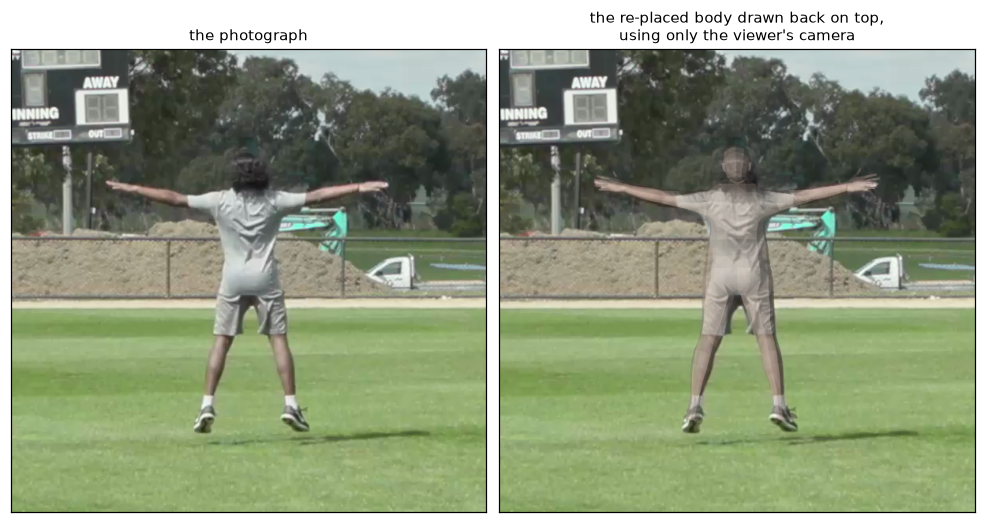

In [8]:
photo = video_frame(VIDEOS / subject / f"{subject}-{clip_id}-{view}.mkv", index)
full_viewer = render.Camera(focal=float(K[0, 0]), center=(float(K[0, 2]), float(K[1, 2])),
                            size=(photo.shape[1], photo.shape[0]),
                            rotation=viewer_rotation, translation=viewer_translation)
overlay = render.render(mesh_after, triangles, full_viewer, background=photo, alpha=0.55)

box = subject_box(placed, full_viewer, margin=120)
x1, y1, x2, y2 = box

figure, axes = plt.subplots(1, 2, figsize=(9, 5.2))
axes[0].imshow(photo[y1:y2, x1:x2])
axes[0].set(title="the photograph", xticks=[], yticks=[])
axes[1].imshow(overlay[y1:y2, x1:x2])
axes[1].set(title="the re-placed body drawn back on top,\nusing only the viewer's camera",
            xticks=[], yticks=[])
plt.tight_layout(); plt.show()

Note the one joint left out of that comparison: `body_world`. It is not part of the body — it is a
fixed marker sitting at the origin of MHR's world, and moving the body relative to it is the
entire point. Including it would report the move itself as an error, which is exactly the mistake
that showed up the first time these checks were written.

## 5. The body in its own frame, interactive

Now the payoff. The body is standing in a clean frame with the viewer at the origin, so we can
walk around it. Drag to rotate, scroll to zoom.

The floor is drawn at the body's lowest point and the red arrow is the direction it faces.

In [10]:
def show_body(pose_in_frame, title):
    """An interactive view of a body that has been placed in the viewer's frame."""
    mesh = ik.mesh_from_pose(rig, pose_in_frame)
    keypoints = ik.posed_keypoints(rig, pose_in_frame)
    centre = mesh.mean(axis=0)
    ground = mesh[:, 1].min()

    # MHR is y-up; plot as (x, z, y) so the figure is z-up.
    traces = [go.Mesh3d(x=mesh[:, 0], y=mesh[:, 2], z=mesh[:, 1],
                        i=triangles[:, 0], j=triangles[:, 1], k=triangles[:, 2],
                        color="lightsteelblue", opacity=0.55, flatshading=False,
                        lighting=dict(ambient=0.55, diffuse=0.7, specular=0.15),
                        name="MHR body", hoverinfo="skip", showscale=False)]

    for a, b in SKELETON:
        pa, pb = keypoints[a], keypoints[b]
        traces.append(go.Scatter3d(x=[pa[0], pb[0]], y=[pa[2], pb[2]], z=[pa[1], pb[1]],
                                   mode="lines", line=dict(color="blue", width=4),
                                   name="skeleton", legendgroup="skeleton",
                                   showlegend=(a, b) == SKELETON[0], hoverinfo="skip"))
    names = list(keypoints)
    xyz = np.array([keypoints[n] for n in names])
    traces.append(go.Scatter3d(x=xyz[:, 0], y=xyz[:, 2], z=xyz[:, 1], mode="markers",
                               marker=dict(size=3, color="blue"), text=names,
                               name="joints", hovertemplate="%{text}<extra></extra>"))

    # A floor, so the eye has something to sit the body on.
    reach = 90.0
    grid = np.array([-reach, reach])
    traces.append(go.Surface(x=centre[0] + grid, y=centre[2] + grid,
                             z=np.full((2, 2), ground),
                             colorscale=[[0, "gainsboro"], [1, "gainsboro"]],
                             opacity=0.35, showscale=False, hoverinfo="skip", name="floor"))

    # Which way is it facing?
    facing = vf.facing_direction(rig, pose_in_frame) * 70.0
    hips = keypoints["pelvis"]
    traces.append(go.Scatter3d(x=[hips[0], hips[0] + facing[0]], y=[hips[2], hips[2] + facing[2]],
                               z=[hips[1], hips[1] + facing[1]], mode="lines",
                               line=dict(color="red", width=7), name="facing", hoverinfo="skip"))

    figure = go.Figure(traces)
    figure.update_layout(title=title, width=760, height=660,
                         margin=dict(l=0, r=0, t=60, b=0),
                         scene=dict(xaxis_title="x (cm)", yaxis_title="z (cm)", zaxis_title="y (cm)",
                                    aspectmode="data",
                                    camera=dict(eye=dict(x=0.0, y=-2.0, z=0.6))))
    return figure

turn = vf.turn_towards_viewer(rig, placed)
show_body(placed, f"the athlete, in the viewer's own frame<br>"
                  f"<sub>{vf.distance_to_viewer(rig, placed)/100:.2f} m from the viewer &middot; "
                  f"{vf.describe_turn(turn)} ({turn:+.0f}&deg;)</sub>").show()

The interactive view is zoomed to the body, so the viewer at the origin is off-screen. A plan view
puts the whole arrangement back together: the camera, the body eighteen metres out, and which way
it is pointing.

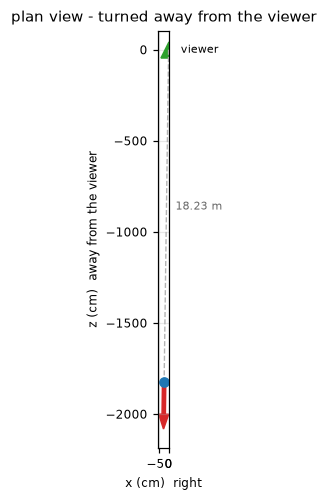

In [11]:
def plan_view(ax, pose_in_frame, title):
    """Looking straight down on the viewer's frame: camera at the origin, body out at -z."""
    keypoints = ik.posed_keypoints(rig, pose_in_frame)
    hips = keypoints["pelvis"]
    facing = vf.facing_direction(rig, pose_in_frame)
    distance = vf.distance_to_viewer(rig, pose_in_frame)

    ax.plot([0], [0], marker="^", markersize=11, color="tab:green")
    ax.annotate("viewer", (0, 0), textcoords="offset points", xytext=(8, -2), fontsize=7)
    ax.plot([0, hips[0]], [0, hips[2]], color="0.7", lw=0.9, ls="--")
    ax.annotate(f"{distance/100:.2f} m", (hips[0] / 2, hips[2] / 2),
                textcoords="offset points", xytext=(6, 4), fontsize=7, color="0.4")

    ax.plot([hips[0]], [hips[2]], marker="o", markersize=6, color="tab:blue")
    ax.arrow(hips[0], hips[2], facing[0] * 260, facing[2] * 260,
             color="tab:red", width=18, length_includes_head=True)
    ax.set(title=title, xlabel="x (cm)  right", ylabel="z (cm)  away from the viewer")
    ax.set_aspect("equal"); ax.grid(alpha=0.3)

figure, ax = plt.subplots(figsize=(4.6, 4.6))
plan_view(ax, placed, f"plan view - {vf.describe_turn(turn)}")
plt.tight_layout(); plt.show()

## 6. Turned away, side-on, facing the camera

The point of all this is that the body's heading relative to the camera survives. So here are
three frames chosen from the dataset by measuring that heading — one with the athlete's back to
the camera, one side-on, one facing it — with the photograph beside the re-placed body.

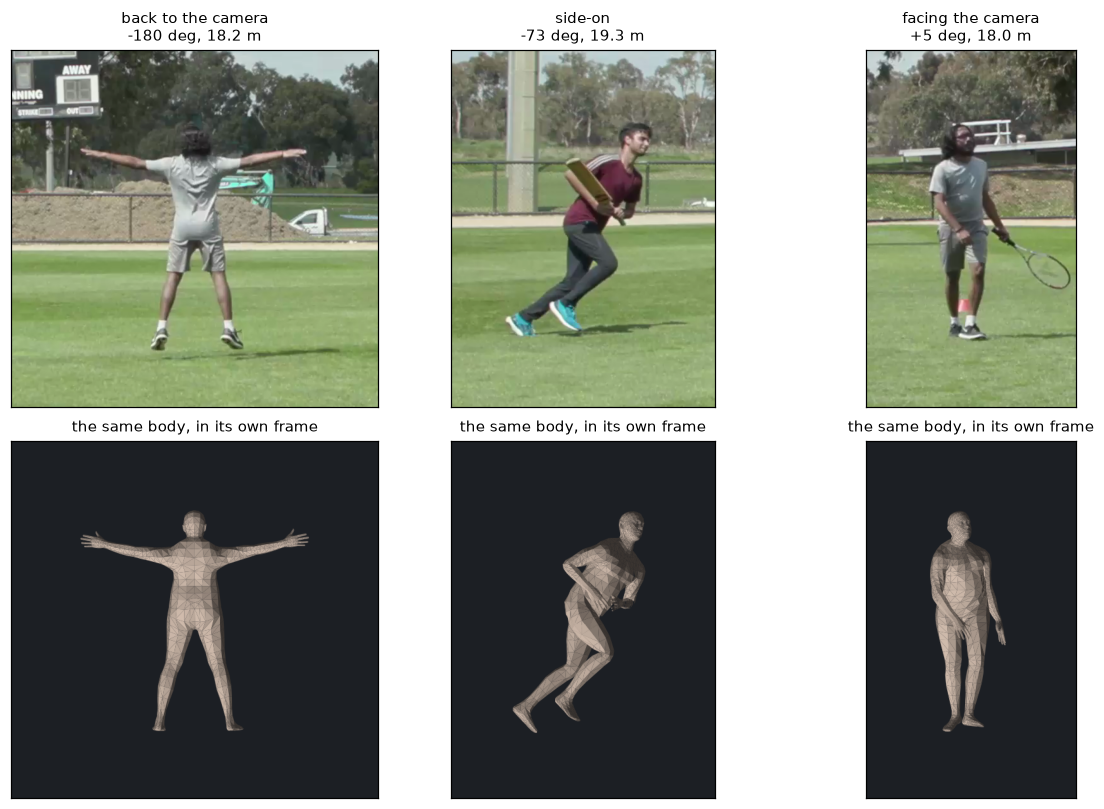

In [12]:
EXAMPLES = [("8a59", "0006", "mid", 50, "back to the camera"),
            ("1e28", "0046", "left", 175, "side-on"),
            ("8a59", "0068", "right", 150, "facing the camera")]

def prepare(subject, clip_id, view, index):
    """Solve one frame, re-place it, and gather what we need to draw it."""
    frames = load_clip(JOINTS_DIR / subject / f"{subject}-{clip_id}.c3d")
    intrinsics, extrinsics = read_camera(subject, view)
    rotation, translation = vf.camera_from_aspset(extrinsics)
    _, pose_here = solve_frame(frames[index])
    placed_here = vf.place_in_viewer_frame(rig, pose_here, rotation, translation)

    photo = video_frame(VIDEOS / subject / f"{subject}-{clip_id}-{view}.mkv", index)
    real = render.Camera(focal=float(intrinsics[0, 0]),
                         center=(float(intrinsics[0, 2]), float(intrinsics[1, 2])),
                         size=(photo.shape[1], photo.shape[0]),
                         rotation=rotation, translation=translation)
    return placed_here, photo, intrinsics, subject_box(pose_here, real)

figure, axes = plt.subplots(2, len(EXAMPLES), figsize=(11, 7.4))
for column, (subject, clip_id, view, index, label) in enumerate(EXAMPLES):
    placed_here, photo, intrinsics, box = prepare(subject, clip_id, view, index)
    x1, y1, x2, y2 = box
    camera = crop_camera(intrinsics, box)

    axes[0, column].imshow(photo[y1:y2, x1:x2])
    turn_here = vf.turn_towards_viewer(rig, placed_here)
    axes[0, column].set(title=f"{label}\n{turn_here:+.0f} deg, "
                              f"{vf.distance_to_viewer(rig, placed_here)/100:.1f} m",
                        xticks=[], yticks=[])

    body_image = render.render(ik.mesh_from_pose(rig, placed_here), triangles, camera)
    axes[1, column].imshow(body_image)
    axes[1, column].set(title="the same body, in its own frame", xticks=[], yticks=[])
plt.tight_layout(); plt.show()

In [13]:
# The two rows are the same size, because cropping the photograph and cropping the
# camera are the same operation. Nothing was stretched to make them agree.
for subject, clip_id, view, index, label in EXAMPLES:
    placed_here, photo, intrinsics, box = prepare(subject, clip_id, view, index)
    x1, y1, x2, y2 = box
    camera = crop_camera(intrinsics, box)
    cropped = photo[y1:y2, x1:x2]
    print(f"{label:<22s} photograph {cropped.shape[1]}x{cropped.shape[0]} px, "
          f"render {camera.size[0]}x{camera.size[1]} px")
print("Top row: the photograph. Bottom row: the re-placed mesh, rendered from the viewer's")
print("position in its own frame. The heading and the distance carried over exactly, so the")
print("two rows line up -- but the bottom one now lives in a frame you can walk around.")

back to the camera     photograph 582x566 px, render 582x566 px
side-on                photograph 410x555 px, render 410x555 px
facing the camera      photograph 330x561 px, render 330x561 px
Top row: the photograph. Bottom row: the re-placed mesh, rendered from the viewer's
position in its own frame. The heading and the distance carried over exactly, so the
two rows line up -- but the bottom one now lives in a frame you can walk around.


In [14]:
# The claim from section 1, tested: someone facing the camera lands in MHR's rest orientation.
print(f"{'example':<22s} {'turn':>8s}   {'facing direction in the viewer frame':<38s} {'words'}")
for subject, clip_id, view, index, label in EXAMPLES:
    placed_here, *_ = prepare(subject, clip_id, view, index)
    turn_here = vf.turn_towards_viewer(rig, placed_here)
    print(f"{label:<22s} {turn_here:+7.1f}   {str(vf.facing_direction(rig, placed_here).round(3)):<38s} "
          f"{vf.describe_turn(turn_here)}")
print(f"\na body at rest in MHR faces {vf.BODY_FACES.astype(int)}, and the one facing the camera")
print("comes out very close to that -- which is what makes -z the natural way for the viewer to look.")

example                    turn   facing direction in the viewer frame   words
back to the camera      -180.0   [-0.013  0.044 -0.999]                 turned away from the viewer
side-on                  -73.4   [ 0.841 -0.541 -0.006]                 side-on, facing the viewer's left
facing the camera         +5.0   [-0.001 -0.217  0.976]                 facing the viewer

a body at rest in MHR faces [0 0 1], and the one facing the camera
comes out very close to that -- which is what makes -z the natural way for the viewer to look.


One thing to notice, because it is not an error: the mesh is a heavier build than the athlete.
`analytic_ik` fits the *pose* and the bone *lengths*, and never touches MHR's 45 identity
coefficients — so what you are looking at is MHR's average body wearing the athlete's skeleton.
The joints are in the right places; the flesh around them is generic.

## 7. Tested on every clip

One frame proving something is a coincidence; every frame proving it is a property. Below, every
clip in the dataset that has footage, sampled every twenty-fifth frame.

In [15]:
distance_changes, shape_changes, direction_changes, turns = [], [], [], []
started = time.time()

for video_path in sorted(VIDEOS.rglob("*.mkv")):
    subject, clip_id, view = video_path.stem.split("-")
    frames = load_clip(JOINTS_DIR / subject / f"{subject}-{clip_id}.c3d")
    _, extrinsics = read_camera(subject, view)
    rotation, translation = vf.camera_from_aspset(extrinsics)

    for index in range(0, len(frames), 25):
        _, pose_here = solve_frame(frames[index])
        placed_here = vf.place_in_viewer_frame(rig, pose_here, rotation, translation)

        original, _ = rig.forward_kinematics(pose_here)
        was = np.linalg.norm(rotation @ original[root] + translation)
        distance_changes.append(abs(was - vf.distance_to_viewer(rig, placed_here)))
        shape_changes.append(vf.largest_shape_change(rig, pose_here, placed_here))
        direction_changes.append(vf.largest_direction_change(rig, pose_here, placed_here, rotation))
        turns.append(vf.turn_towards_viewer(rig, placed_here))

distance_changes = np.array(distance_changes)
shape_changes = np.array(shape_changes)
direction_changes = np.array(direction_changes)
turns = np.array(turns)

print(f"{len(turns)} frames from 60 clips, {1000*(time.time()-started)/len(turns):.0f} ms per frame\n")
print(f"{'what must not change':<44s} {'mean':>12s} {'worst':>12s}")
print(f"{'distance from the camera (cm)':<44s} {distance_changes.mean():>12.2e} {distance_changes.max():>12.2e}")
print(f"{'gap between any two joints (cm)':<44s} {shape_changes.mean():>12.2e} {shape_changes.max():>12.2e}")
print(f"{'bone direction as the camera sees it (deg)':<44s} {direction_changes.mean():>12.2e} {direction_changes.max():>12.2e}")

575 frames from 60 clips, 38 ms per frame

what must not change                                 mean        worst
distance from the camera (cm)                    6.78e-05     3.46e-04
gap between any two joints (cm)                  1.43e-04     4.16e-04
bone direction as the camera sees it (deg)       3.56e-03     1.32e-02


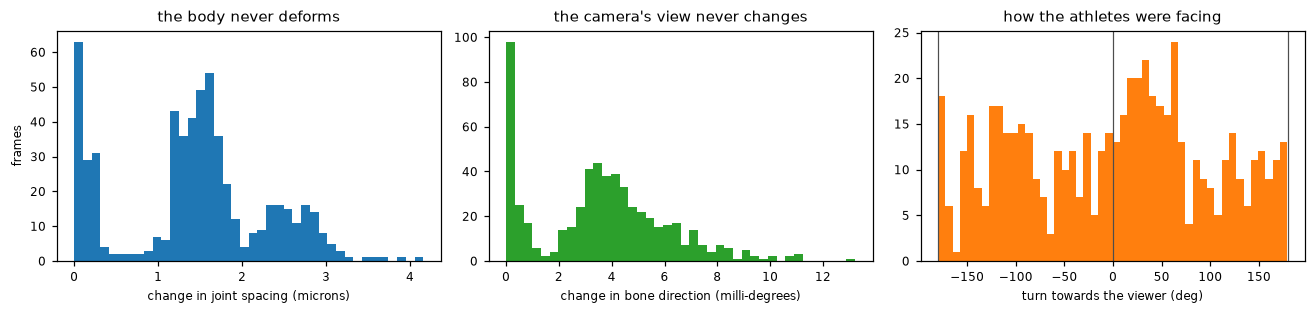

facing the viewer (|turn| < 20 deg) :   72 frames
at an angle                        :  450 frames
turned away (|turn| > 160 deg)     :   53 frames

The errors are in microns and milli-degrees -- which is the arithmetic of a change of
coordinates, not of a fit. Nothing is being approximated here.


In [16]:
figure, axes = plt.subplots(1, 3, figsize=(12, 2.9))
axes[0].hist(shape_changes * 1e4, bins=40, color="tab:blue")
axes[0].set(xlabel="change in joint spacing (microns)", ylabel="frames",
            title="the body never deforms")
axes[1].hist(direction_changes * 1e3, bins=40, color="tab:green")
axes[1].set(xlabel="change in bone direction (milli-degrees)",
            title="the camera's view never changes")
axes[2].hist(turns, bins=48, color="tab:orange")
axes[2].set(xlabel="turn towards the viewer (deg)", title="how the athletes were facing")
axes[2].axvline(0, color="0.3", lw=0.8); axes[2].axvline(180, color="0.3", lw=0.8)
axes[2].axvline(-180, color="0.3", lw=0.8)
plt.tight_layout(); plt.show()

print(f"facing the viewer (|turn| < 20 deg) : {(np.abs(turns) < 20).sum():4d} frames")
print(f"at an angle                        : {((np.abs(turns) >= 20) & (np.abs(turns) <= 160)).sum():4d} frames")
print(f"turned away (|turn| > 160 deg)     : {(np.abs(turns) > 160).sum():4d} frames")
print("\nThe errors are in microns and milli-degrees -- which is the arithmetic of a change of")
print("coordinates, not of a fit. Nothing is being approximated here.")

## 8. A video, and the body beside it

Finally the thing this was built for: play a clip and watch the re-placed body alongside it. Three
panels per frame —

* the footage, cropped to the athlete;
* the re-placed body seen from the viewer's own position, which should track the footage;
* the same body from a raised viewpoint forty degrees round, which is only possible *because* it
  now lives in a frame of its own.

The middle panel is the honesty check and the right panel is the point.

In [17]:
def build_clip(subject, clip_id, view, step=6, height=300, azimuth=40, elevation=12):
    """Return a list of side-by-side pictures: footage | viewer's view | walked around."""
    frames = load_clip(JOINTS_DIR / subject / f"{subject}-{clip_id}.c3d")
    intrinsics, extrinsics = read_camera(subject, view)
    rotation, translation = vf.camera_from_aspset(extrinsics)
    indices = list(range(0, len(frames), step))

    real = render.Camera(focal=float(intrinsics[0, 0]),
                         center=(float(intrinsics[0, 2]), float(intrinsics[1, 2])),
                         size=(3840, 2160), rotation=rotation, translation=translation)

    # Solve every frame first, so one crop box can cover the whole clip and the
    # footage does not jitter about.
    placed_poses, boxes = [], []
    for index in indices:
        _, pose_here = solve_frame(frames[index])
        placed_poses.append(vf.place_in_viewer_frame(rig, pose_here, rotation, translation))
        boxes.append(subject_box(pose_here, real))
    boxes = np.array(boxes)
    box = (boxes[:, 0].min(), boxes[:, 1].min(), boxes[:, 2].max(), boxes[:, 3].max())
    x1, y1, x2, y2 = box

    camera = crop_camera(intrinsics, box)
    meshes = [ik.mesh_from_pose(rig, placed_here) for placed_here in placed_poses]

    # A second camera that stays put for the whole clip, so the walk-around is steady.
    walk_around = render.orbit_camera(np.array(meshes), azimuth=azimuth, elevation=elevation,
                                      size=(int(height * 0.8), height))

    capture = cv2.VideoCapture(str(VIDEOS / subject / f"{subject}-{clip_id}-{view}.mkv"))
    pictures = []
    for index, mesh in zip(indices, meshes):
        capture.set(cv2.CAP_PROP_POS_FRAMES, index)
        ok, image = capture.read()
        photo = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)[y1:y2, x1:x2]

        seen = render.render(mesh, triangles, camera)          # same size as `photo`
        around = render.render(mesh, triangles, walk_around)
        pictures.append(np.hstack([shrink(photo, height), shrink(seen, height), around]))
    capture.release()
    return pictures, placed_poses

pictures, placed_poses = build_clip("8a59", "0006", "mid")
print(f"{len(pictures)} frames, each {pictures[0].shape[1]}x{pictures[0].shape[0]} px")
print(f"the athlete is {vf.distance_to_viewer(rig, placed_poses[0])/100:.1f} m away and "
      f"{vf.describe_turn(vf.turn_towards_viewer(rig, placed_poses[0]))}")

42 frames, each 812x300 px
the athlete is 18.2 m away and turned away from the viewer


In [18]:
from IPython.display import Video, display

output = ROOT / "outputs" / "viewer_frame"
output.mkdir(parents=True, exist_ok=True)
clip_file = render.save_video(pictures, output / "own_frame.mp4", fps=8)
print("wrote", clip_file)
display(Video(str(clip_file), embed=True, width=820))

wrote /Users/rzt/Documents/mhr_env/outputs/viewer_frame/own_frame.mp4


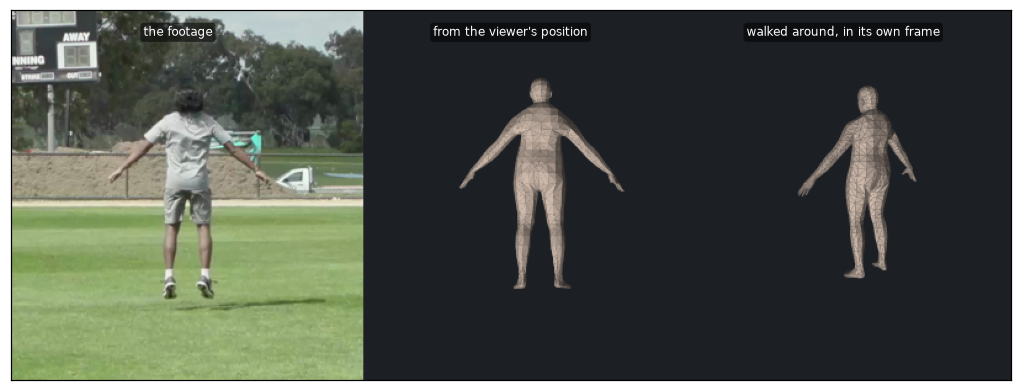

In [19]:
# A still from the middle of that clip, so the three panels can be read side by side.
figure, ax = plt.subplots(figsize=(11, 3.6))
ax.imshow(pictures[len(pictures) // 2])
width = pictures[0].shape[1] // 3
for x, label in ((width * 0.5, "the footage"),
                 (width * 1.5, "from the viewer's position"),
                 (width * 2.5, "walked around, in its own frame")):
    ax.text(x, 12, label, ha="center", va="top", fontsize=8, color="white",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="black", alpha=0.55, linewidth=0))
ax.set(xticks=[], yticks=[])
plt.tight_layout(); plt.show()

In [20]:
# And the same clip's last frame, interactive, to finish where we started.
show_body(placed_poses[-1],
          f"the last frame of the clip, in its own frame<br>"
          f"<sub>{vf.distance_to_viewer(rig, placed_poses[-1])/100:.2f} m from the viewer &middot; "
          f"{vf.describe_turn(vf.turn_towards_viewer(rig, placed_poses[-1]))}</sub>").show()

## Summary

[`viewer_frame.py`](../viewer_frame.py) — about 120 lines of code. It does one thing: it moves a
solved body into a frame of its own, and it changes nothing else.

**How.** Move the scene, not the body. Work out where the body sits as the camera sees it, say
the same thing with y pointing up, and write that one place and one heading into the root. Every
joint angle is left exactly as the solver produced it — six parameters change out of 204.

**Why only the root needs touching.** Two measured facts: turning the root does not move it, and
`root_tx/ty/tz` slide the body along the world axes at 10 cm per unit regardless of the turn. So
the place and the heading can be written independently.

**Why −z.** A body at rest in MHR faces +z, so a viewer at the origin looking along −z sees its
front. A person who was facing the camera therefore lands in the rig's own rest orientation
(§6 checks this), and the camera-to-viewer change is a real rotation rather than a mirror, so
left hands stay left hands.

**What it preserves, measured over 575 frames of every clip in the dataset:**

| | |
|---|---|
| distance from the camera | 0.0003 cm |
| distance between any two joints | 0.0004 cm |
| any bone's direction, as the camera sees it | 0.013° |
| where the body lands in the photograph | 0.0004 px in a 4K image |

Those are the residuals of 32-bit arithmetic, not of an approximation — a change of coordinates
has no error of its own.

**Two things worth knowing.**

1. **The body is upright only if the camera was level.** The heading relative to the camera is
   preserved exactly, and that is what was asked for — so if the real camera was tilted, the body
   is tilted in the new frame too, because that is what the camera saw. The floor drawn in §5
   sits at the body's lowest point, not at a true ground plane.
2. **Two of the checks have to skip some joints, for real reasons.** `body_world` is a fixed
   marker at the origin rather than part of the body, and moving the body relative to it is the
   whole point. And MHR has bones only millimetres long — the ankle has one, as do the twist and
   eye markers — whose direction is meaningless when forward kinematics runs in 32-bit floats
   twenty metres from the origin. Both exclusions are in the code with the reason beside them.

/Users/rzt/Documents/mhr_env/.venv/lib/python3.13/site-packages/c3d/c3d.py:1219: UserWarning: No analog data found in file.
  warnings.warn('No analog data found in file.')


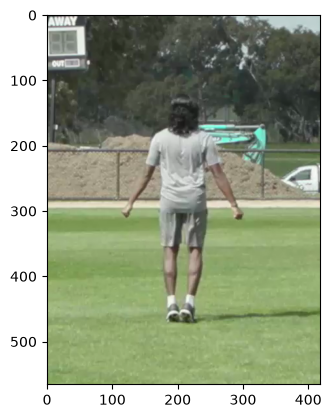

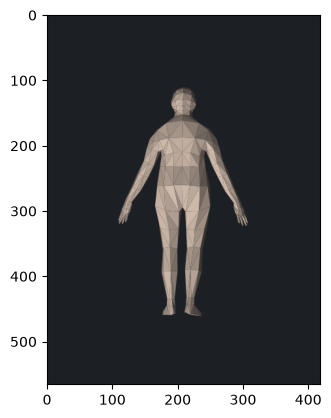

In [1]:
import sys, pathlib, time, warnings, json, collections
import numpy as np
import matplotlib.pyplot as plt
import cv2
import plotly.graph_objects as go
import viewer_frame as vf
import c3d
import analytic_ik as ik
from mhr_kit.model import faces
from mhr_kit import render

rig = ik.Rig() 


ROOT = pathlib.Path.cwd()
CAMERAS = ROOT / "ASPset" / "ASPset-510 3" / "test" / "cameras"
VIDEOS  = ROOT / "ASPset" / "ASPset-510" / "test" / "videos"
JOINTS_DIR = ROOT / "ASPset" / "ASPset-510 4" / "test" / "joints_3d"

SKELETON = [("pelvis", "neck"), ("neck", "head"), ("head", "head_top"),
            ("neck", "left_shoulder"), ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
            ("neck", "right_shoulder"), ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
            ("pelvis", "left_hip"), ("left_hip", "left_knee"), ("left_knee", "left_ankle"),
            ("pelvis", "right_hip"), ("right_hip", "right_knee"), ("right_knee", "right_ankle")]

def load_clip(path):
    with open(path, "rb") as f:
        return np.array([points for _, points, _ in c3d.Reader(f).read_frames()])[:, :, :3]

def read_camera(subject, view):
    data = json.loads((CAMERAS / subject / f"{subject}-{view}.json").read_text())
    return (np.array(data["intrinsic_matrix"]).reshape(3, 4),
            np.array(data["extrinsic_matrix"]).reshape(4, 4))

def crop_camera(intrinsics, box):
    """The viewer's camera, cropped to `box`.

    Cropping an image only moves the principal point; it does not change the focal
    length. So the render comes out the same size as the cropped photograph and
    lines up with it pixel for pixel, with no resizing anywhere.
    """
    x1, y1, x2, y2 = box
    rotation, translation = vf.viewer_camera()
    return render.Camera(focal=float(intrinsics[0, 0]),
                         center=(float(intrinsics[0, 2]) - x1, float(intrinsics[1, 2]) - y1),
                         size=(x2 - x1, y2 - y1),
                         rotation=rotation, translation=translation)

def solve_frame(joints_mm):
    """3D keypoints for one frame -> the target keypoints, and the solved pose."""
    targets = ik.targets_from_aspset(joints_mm)
    pose = ik.solve(rig, targets)
    return targets, pose

def subject_box(pose_here, camera, margin=110):
    """Whole-pixel bounds around the body in the image, for cropping."""
    pixels, _ = camera.project(rig.forward_kinematics(pose_here)[0][vf.body_joints(rig)])
    x1, y1 = np.floor(pixels.min(0) - margin).astype(int)
    x2, y2 = np.ceil(pixels.max(0) + margin).astype(int)
    return x1, y1, x2, y2

def video_frame(path, index):
    capture = cv2.VideoCapture(str(path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, index)
    ok, image = capture.read()
    capture.release()
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def prepare(subject, clip_id, view, index):
    """Solve one frame, re-place it, and gather what we need to draw it."""
    frames = load_clip(JOINTS_DIR / subject / f"{subject}-{clip_id}.c3d")
    intrinsics, extrinsics = read_camera(subject, view)
    rotation, translation = vf.camera_from_aspset(extrinsics)
    _, pose_here = solve_frame(frames[index])
    placed_here = vf.place_in_viewer_frame(rig, pose_here, rotation, translation)

    photo = video_frame(VIDEOS / subject / f"{subject}-{clip_id}-{view}.mkv", index)
    real = render.Camera(focal=float(intrinsics[0, 0]),
                         center=(float(intrinsics[0, 2]), float(intrinsics[1, 2])),
                         size=(photo.shape[1], photo.shape[0]),
                         rotation=rotation, translation=translation)
    return placed_here, photo, intrinsics, subject_box(pose_here, real)

def show_mesh_3d(vertices, triangles, keypoints=None, skeleton=None, name_order=None):
    """Interactive 3D view of the MHR mesh, with an optional skeleton overlay."""
    verts = np.asarray(vertices, dtype=float)
    tris = np.asarray(triangles, dtype=int)

    data = [go.Mesh3d(
        x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
        i=tris[:, 0], j=tris[:, 1], k=tris[:, 2],
        color="lightsteelblue", opacity=1.0, flatshading=False,
        lighting=dict(ambient=0.45, diffuse=0.85, specular=0.25, roughness=0.6),
        lightposition=dict(x=1000, y=1000, z=2000),
        hoverinfo="skip", name="mesh")]

    if keypoints is not None:
        pts = np.asarray(keypoints, dtype=float)
        labels = list(name_order) if name_order is not None else [str(i) for i in range(len(pts))]
        data.append(go.Scatter3d(
            x=pts[:, 0], y=pts[:, 1], z=pts[:, 2], mode="markers",
            marker=dict(size=3, color="crimson"), text=labels,
            hovertemplate="%{text}<extra></extra>", name="joints"))

        if skeleton is not None:
            lookup = {n: i for i, n in enumerate(labels)}
            seg = []
            for a, b in skeleton:
                if a in lookup and b in lookup:
                    seg += [pts[lookup[a]], pts[lookup[b]], [np.nan] * 3]
            if seg:
                seg = np.asarray(seg, dtype=float)
                data.append(go.Scatter3d(
                    x=seg[:, 0], y=seg[:, 1], z=seg[:, 2], mode="lines",
                    line=dict(width=4, color="crimson"), hoverinfo="skip", name="bones"))

    # Equal scaling on all three axes so the body isn't stretched.
    span = (verts.max(0) - verts.min(0)).max()
    mid = (verts.max(0) + verts.min(0)) / 2
    axis = lambda c: dict(range=[mid[c] - span / 2, mid[c] + span / 2],
                          showbackground=False, title=("x", "y", "z")[c])

    fig = go.Figure(data=data)
    fig.update_layout(
        scene=dict(xaxis=axis(0), yaxis=axis(1), zaxis=axis(2),
                   aspectmode="cube",
                   camera=dict(eye=dict(x=0, y=-2.0, z=0), up=dict(x=0, y=0, z=1))),
        margin=dict(l=0, r=0, t=30, b=0), height=750,
        title=f"{subject}-{clip_id}-{view} frame {index}")
    fig.show()
    return fig


video_path = sorted(VIDEOS.rglob("*.mkv"))[30]
subject, clip_id, view = video_path.stem.split("-")
frames = load_clip(JOINTS_DIR / subject / f"{subject}-{clip_id}.c3d")
K, E = read_camera(subject, view)
order = list(ik.TARGET_TO_RIG)

index = 90
photo = video_frame(video_path, index)
target_points = ik.targets_from_aspset(frames[index])
pose = ik.solve(rig, target_points)
solved_points = ik.posed_keypoints(rig, pose)

mesh = ik.mesh_from_pose(rig, pose)
vertices = np.asarray(getattr(mesh, "vertices", mesh), dtype=float)
triangles = np.asarray(faces(rig.model), dtype=int)

placed_here, photo, intrinsics, box = prepare(subject, clip_id, view, index)
x1, y1, x2, y2 = box
camera = crop_camera(intrinsics, box)

plt.imshow(photo[y1:y2, x1:x2])
plt.show()

turn_here = vf.turn_towards_viewer(rig, placed_here)

body_image = render.render(ik.mesh_from_pose(rig, placed_here), triangles, camera)
plt.imshow(body_image)
plt.show()